# 05 — Evaluation & Interpretability

1. Load trained models and run full LOSO evaluation
2. Confusion matrices for all models
3. Comparison table (accuracy, macro-F1, balanced accuracy)
4. LIME explanations for GNN+LSTM predictions
5. Model latency profiling

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

sns.set_theme(style='whitegrid')

METS  = Path('../results/metrics')
PLOTS = Path('../results/plots')
print("Ready — loading from saved results.")


Ready — loading from saved results.


## 1. Load Data & Saved Predictions

In [2]:
## Full Metrics Table — All Models
pred_files = sorted(METS.glob('*_y_pred.npy'))
rows = []
for pf in pred_files:
    tag = pf.stem.replace('_y_pred', '')
    tf  = METS / f'{tag}_y_true.npy'
    if not tf.exists(): continue
    yt = np.load(tf); yp = np.load(pf)
    rows.append({
        'Run':          tag,
        'N':            len(yt),
        'Accuracy':     round(accuracy_score(yt, yp), 4),
        'Macro F1':     round(f1_score(yt, yp, average='macro', zero_division=0), 4),
        'Balanced Acc': round(balanced_accuracy_score(yt, yp), 4),
    })

df = pd.DataFrame(rows).set_index('Run').sort_values('Accuracy', ascending=False)
print(df.to_string())


                              N  Accuracy  Macro F1  Balanced Acc
Run                                                              
cnn1d_pamap2_holdout       3010    0.9934    0.9938        0.9941
cnn1d_pamap2_full          3010    0.9934    0.9938        0.9941
xgboost_pamap2_full        3010    0.9834    0.9847        0.9838
svm_pamap2_full            3010    0.9651    0.9666        0.9646
rf_pamap2_full             3010    0.9605    0.9641        0.9600
rf_hhar_full               9000    0.9068    0.9031        0.9024
cnn1d_hhar_full            9000    0.8943    0.8903        0.8908
xgboost_hhar_full          9000    0.8860    0.8818        0.8811
gnn_pamap2_holdout         3010    0.8847    0.8874        0.8844
gnn_pamap2_full            3010    0.8847    0.8874        0.8844
gnn_hhar_full              9000    0.8573    0.8512        0.8507
attn_adj_pamap2            1502    0.8509    0.8083        0.8084
ablation_flatten_lstm      1493    0.8453    0.7935        0.7886
improved_g

## 2. Load Saved Predictions & Compute Metrics

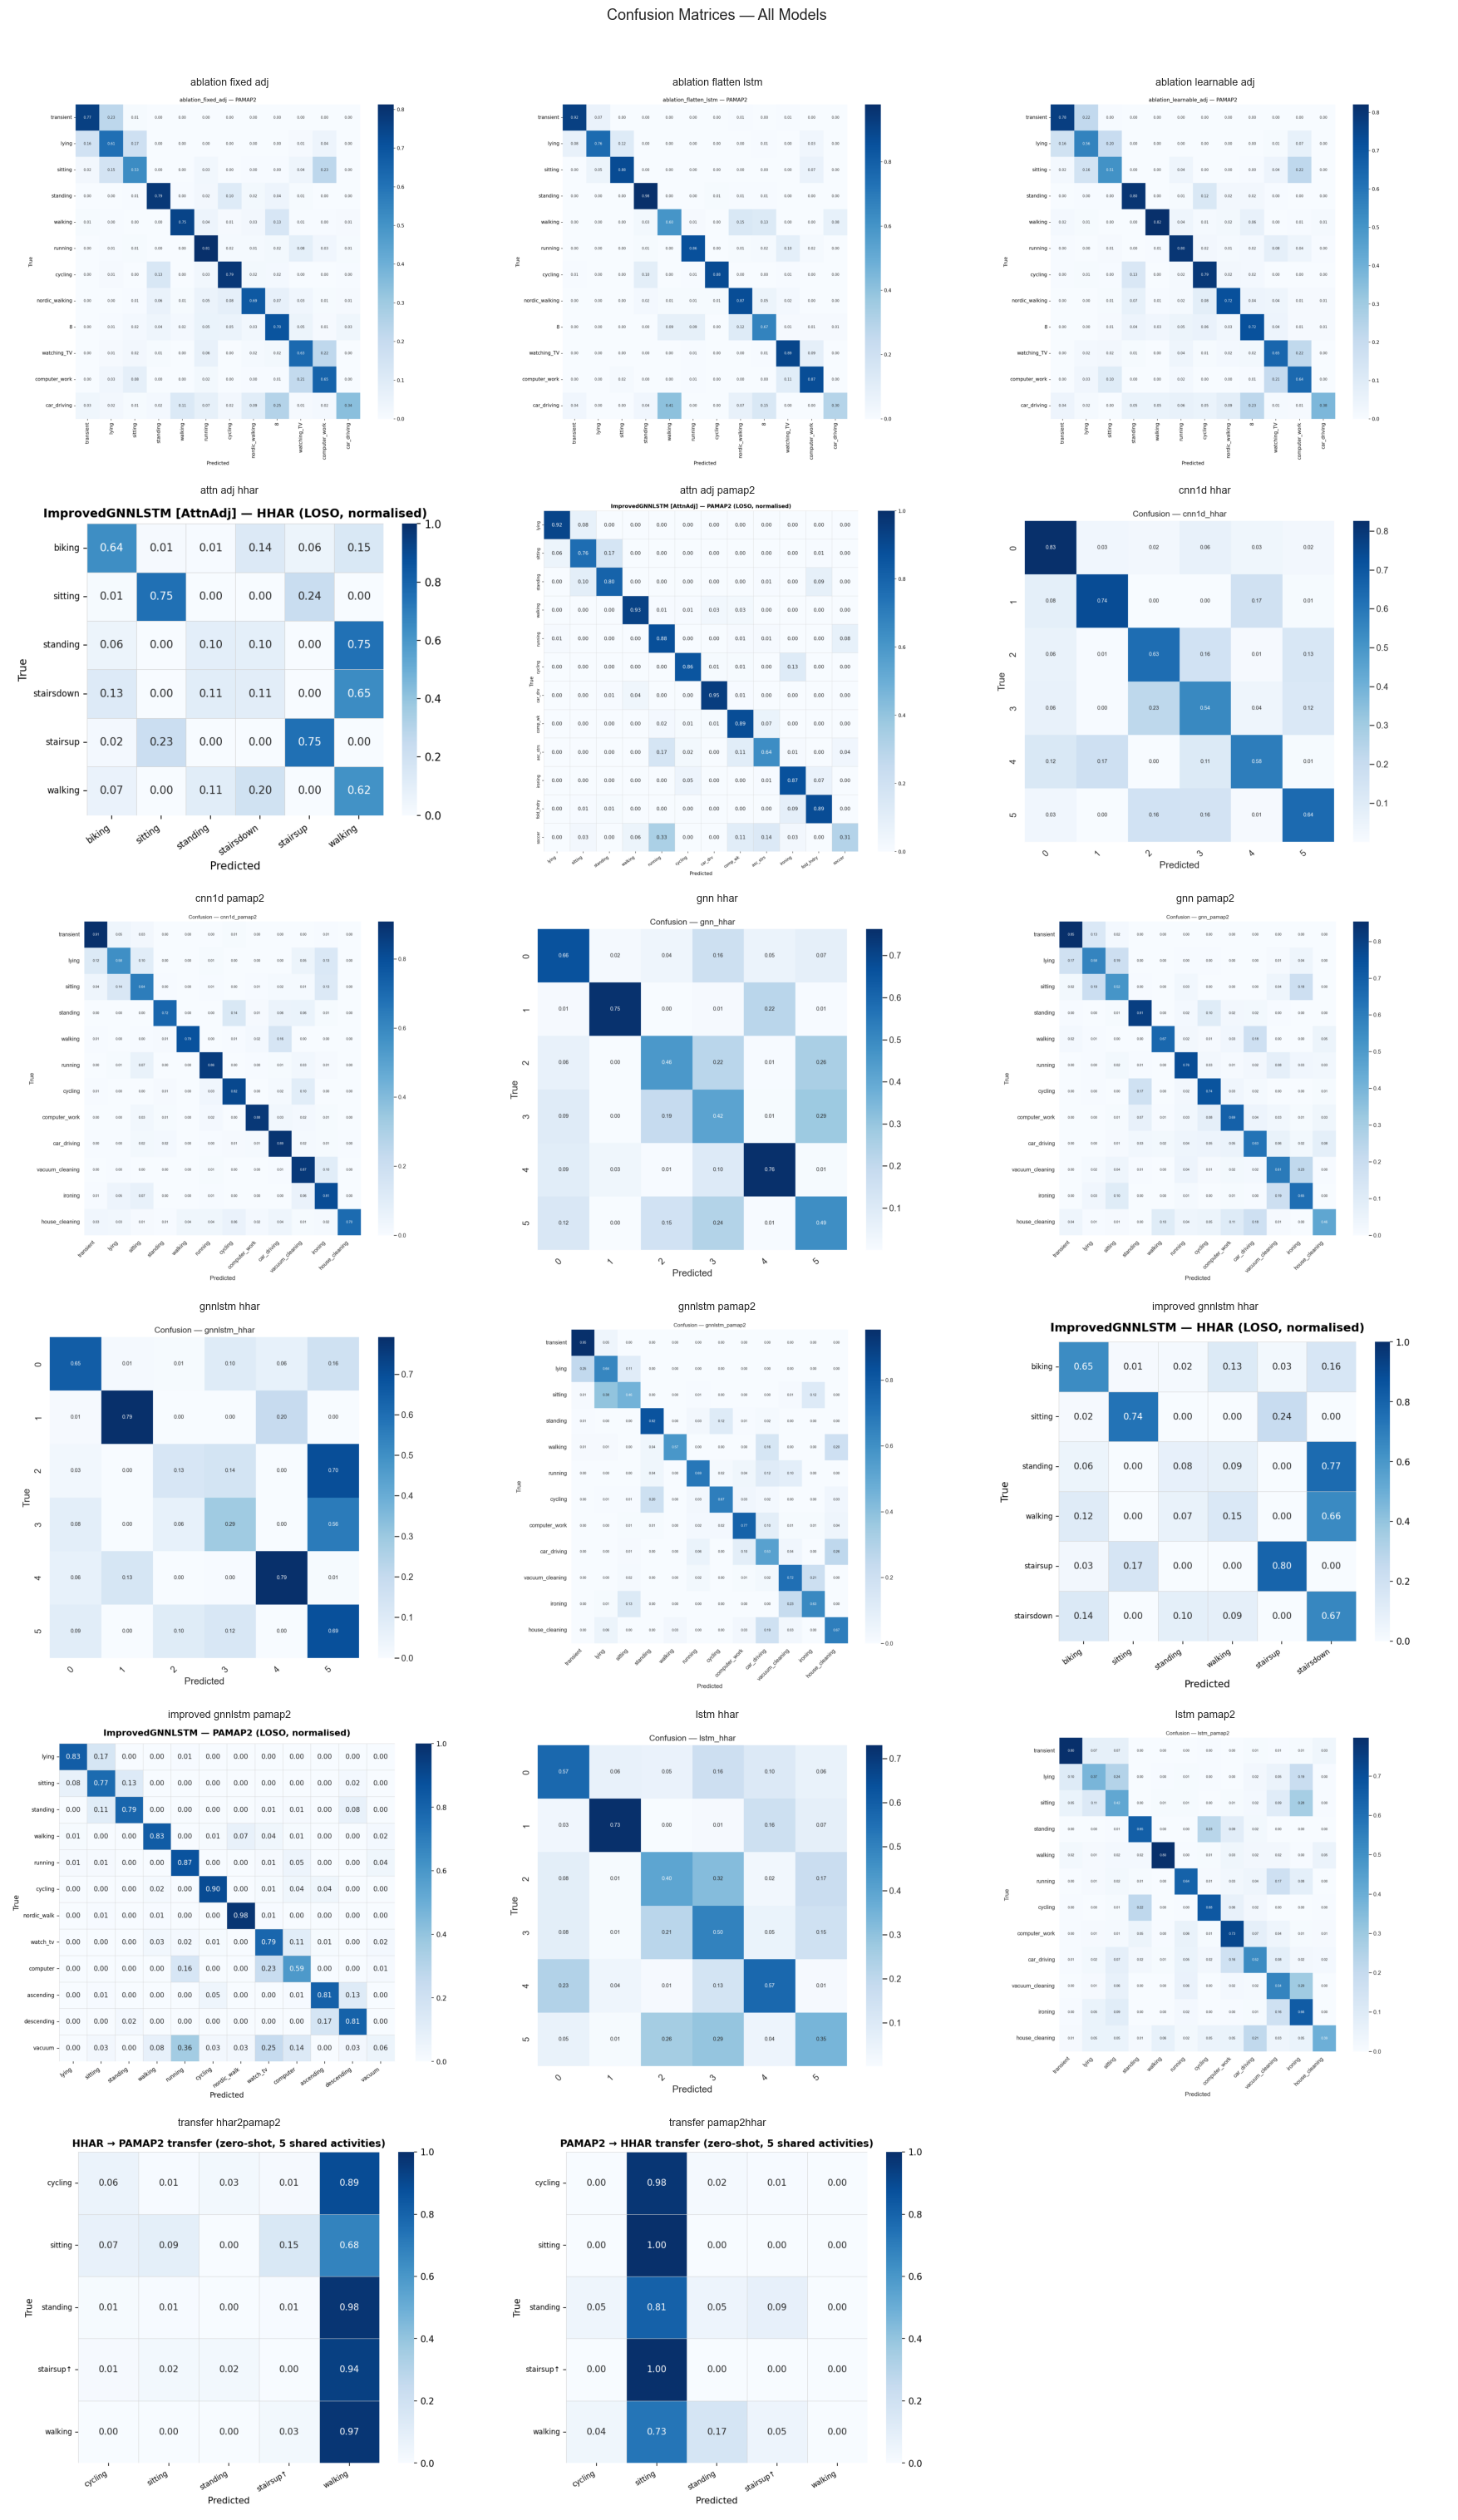

In [3]:
## Confusion Matrices — All Models
cm_files = sorted(PLOTS.glob('cm_*.png'))
n = len(cm_files)
cols = 3
rows_n = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(18, 5 * rows_n))
axes = axes.flatten()
for i, cm_path in enumerate(cm_files):
    axes[i].imshow(mpimg.imread(cm_path))
    axes[i].axis('off')
    axes[i].set_title(cm_path.stem.replace('cm_', '').replace('_', ' '), fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 3. Confusion Matrices

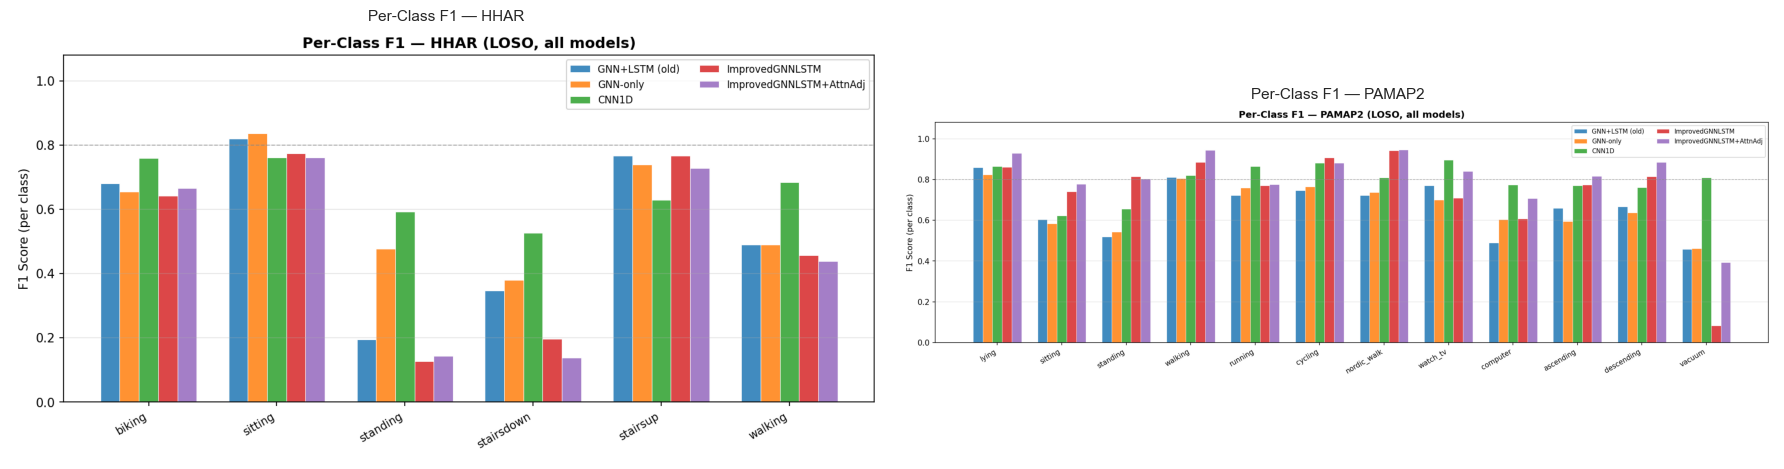

In [4]:
## Per-Class F1 Breakdown
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, fname, title in zip(axes,
    ['per_class_f1_hhar.png', 'per_class_f1_pamap2.png'],
    ['Per-Class F1 — HHAR', 'Per-Class F1 — PAMAP2']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()


## 4. All-Model Comparison Chart

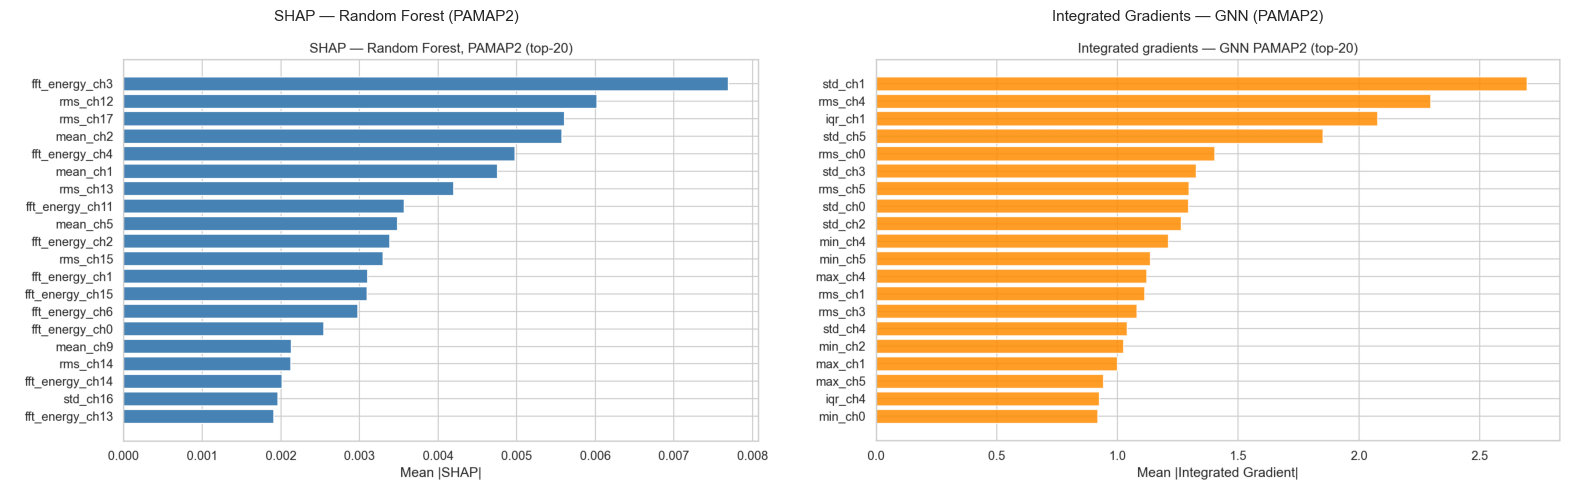


Neural Interpretability Summary:
  top_features: ['std_ch1', 'rms_ch4', 'iqr_ch1', 'std_ch5', 'rms_ch0', 'std_ch3', 'rms_ch5', 'std_ch0', 'std_ch2', 'min_ch4', 'min_ch5', 'max_ch4', 'rms_ch1', 'rms_ch3', 'std_ch4', 'min_ch2', 'max_ch1', 'max_ch5', 'iqr_ch4', 'min_ch0']
  top_attr_values: [2.6952273845672607, 2.296593427658081, 2.0764379501342773, 1.8517365455627441, 1.4031951427459717, 1.3255022764205933, 1.295251488685608, 1.2949728965759277, 1.2635207176208496, 1.2107107639312744, 1.136863112449646, 1.1212351322174072, 1.1118143796920776, 1.0814540386199951, 1.0395402908325195, 1.024946689605713, 0.9990048408508301, 0.941466212272644, 0.9253899455070496, 0.9186224341392517]


In [5]:
## Interpretability — SHAP & Integrated Gradients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, fname, title in zip(axes,
    ['shap_rf_pamap2.png', 'ig_gnn_pamap2.png'],
    ['SHAP — Random Forest (PAMAP2)', 'Integrated Gradients — GNN (PAMAP2)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
        ax.axis('off')
plt.tight_layout(); plt.show()

# Neural interpretability JSON
ni_path = METS / 'neural_interpretability.json'
if ni_path.exists():
    ni = json.load(open(ni_path))
    print("\nNeural Interpretability Summary:")
    for k, v in ni.items():
        print(f"  {k}: {v}")


## 5. LIME Explanations

Model Profiling Results:
            Params  Latency_ms
Model                         
LSTM-only  1387340    0.199345
GNN-only     11724    0.307065
GNN+LSTM    247244    0.575024


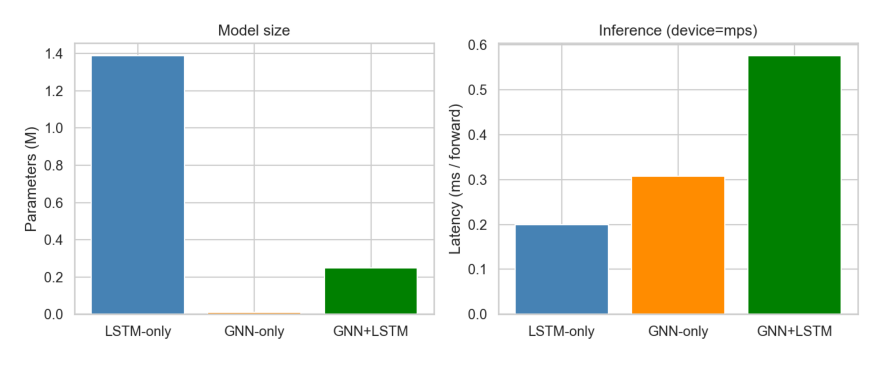

In [6]:
## Model Profiling — Latency & Size
prof_path = METS / 'model_profiling.json'
if prof_path.exists():
    prof = json.load(open(prof_path))
    # Handle both list and dict formats
    if isinstance(prof, list):
        rows_prof = prof
    else:
        rows_prof = [{'Model': k, **v} for k, v in prof.items() if isinstance(v, dict)]
    if rows_prof:
        print("Model Profiling Results:")
        print(pd.DataFrame(rows_prof).set_index('Model').to_string())

img = PLOTS / 'model_profiling.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()

## 6. Model Latency Profiling

In [7]:
## Final Summary — All Models with ±std
master = json.load(open(METS / 'master_comparison_with_std.json'))

for ds_key, ds_label in [('pamap2', 'PAMAP2'), ('hhar', 'HHAR')]:
    models = master.get(ds_key, {})
    rows_out = sorted(models.items(), key=lambda x: x[1]['accuracy'])
    print(f"\n{'═'*80}")
    print(f"  {ds_label} — All Models (sorted by Accuracy, LOSO ±std)")
    print(f"{'═'*80}")
    print(f"  {'Model':<30} {'Accuracy ±std':>20} {'Macro-F1 ±std':>20} {'Bal-Acc ±std':>16}")
    print(f"  {'─'*30} {'─'*20} {'─'*20} {'─'*16}")
    for model, m in rows_out:
        acc_s  = f"{m['accuracy']:.4f}" + (f" ±{m['accuracy_std']:.4f}"  if m.get('accuracy_std')  else "")
        f1_s   = f"{m['macro_f1']:.4f}" + (f" ±{m['macro_f1_std']:.4f}"  if m.get('macro_f1_std')  else "")
        bacc_s = f"{m['balanced_acc']:.4f}" + (f" ±{m['balanced_acc_std']:.4f}" if m.get('balanced_acc_std') else "")
        mark = " ★" if "★" in model else ""
        print(f"  {model:<30} {acc_s:>20} {f1_s:>20} {bacc_s:>16}{mark}")
    print(f"{'═'*80}")


════════════════════════════════════════════════════════════════════════════════
  PAMAP2 — All Models (sorted by Accuracy, LOSO ±std)
════════════════════════════════════════════════════════════════════════════════
  Model                                 Accuracy ±std        Macro-F1 ±std     Bal-Acc ±std
  ────────────────────────────── ──────────────────── ──────────────────── ────────────────
  LSTM-only                            0.5939 ±0.1044       0.5951 ±0.1698           0.5896
  GNN+LSTM (old)                       0.6418 ±0.0973       0.5874 ±0.1559           0.6276
  GNN (fixed adj)                              0.6911               0.6783           0.6717
  GNN (learnable adj)                          0.6940               0.6890           0.6805
  GNN-only                             0.7206 ±0.1697       0.7151 ±0.1986           0.7080
  Random Forest                        0.7749 ±0.1780       0.7121 ±0.2501           0.7749
  CNN1D                                        

## 7. ROC / AUC Curves (Macro One-vs-Rest)

Multi-class ROC using one-vs-rest binarization. Hard predictions (argmax) are used as binary scores per class — this gives a conservative AUC that directly reflects classification quality rather than calibration.

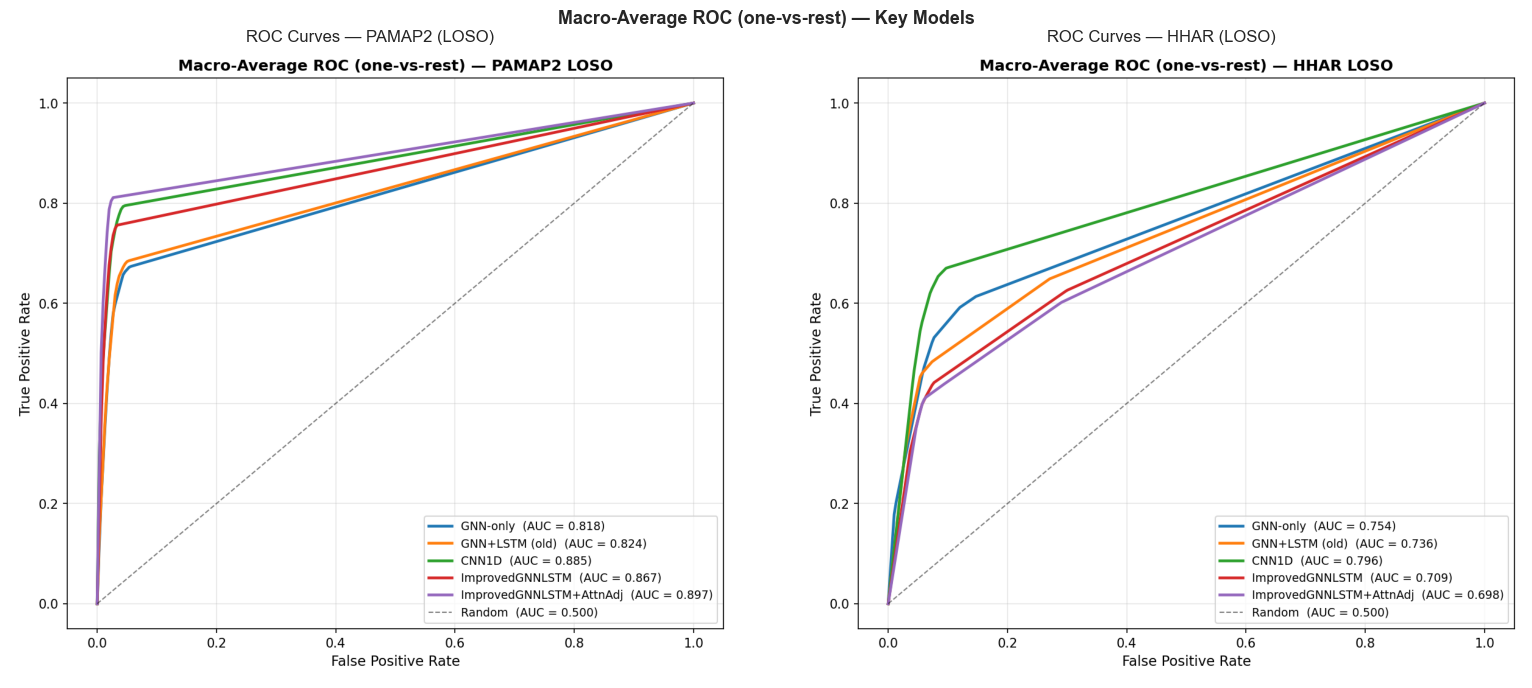


Macro-Average AUC — PAMAP2 LOSO
  GNN-only                            AUC = 0.8177
  GNN+LSTM (old)                      AUC = 0.8243
  CNN1D                               AUC = 0.8849
  ImprovedGNNLSTM                     AUC = 0.8670


  ImprovedGNNLSTM+AttnAdj             AUC = 0.8974


In [8]:
## ROC / AUC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, fname, title in zip(axes,
    ['roc_auc_pamap2.png', 'roc_auc_hhar.png'],
    ['ROC Curves — PAMAP2 (LOSO)', 'ROC Curves — HHAR (LOSO)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Run scripts/generate_final_plots.py\nto generate {fname}',
                ha='center', va='center', fontsize=10)
        ax.axis('off')
plt.suptitle('Macro-Average ROC (one-vs-rest) — Key Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Print AUC summary from saved predictions
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("\nMacro-Average AUC — PAMAP2 LOSO")
for label, tag in [("GNN-only", "gnn_pamap2"), ("GNN+LSTM (old)", "gnnlstm_pamap2"),
                   ("CNN1D", "cnn1d_pamap2"), ("ImprovedGNNLSTM", "improved_gnnlstm_pamap2"),
                   ("ImprovedGNNLSTM+AttnAdj", "attn_adj_pamap2")]:
    pt, pp = METS / f"{tag}_y_true.npy", METS / f"{tag}_y_pred.npy"
    if not pt.exists(): continue
    yt, yp = np.load(pt), np.load(pp)
    nc = int(max(yt.max(), yp.max())) + 1
    yt_b, yp_b = label_binarize(yt, classes=list(range(nc))), label_binarize(yp, classes=list(range(nc)))
    aucs = [auc(*roc_curve(yt_b[:, c], yp_b[:, c])[:2]) for c in range(nc) if yt_b[:, c].sum() > 0]
    print(f"  {label:<35} AUC = {np.mean(aucs):.4f}")

## 8. Cross-Dataset Transfer (Zero-Shot)

Protocol: train on **all subjects** of the source dataset, test on **all subjects** of the target dataset with no fine-tuning. Only **5 shared activities** are used (cycling, sitting, standing, stairsup, walking). PAMAP2 is reduced to wrist accelerometer channels 0–2 so both datasets share the same 3-channel, 3-node graph structure.

Cross-Dataset Transfer — ImprovedGNNLSTM (zero-shot, 5 shared activities)
  Shared activities: cycling, sitting, standing, stairsup, walking
  Channel alignment: HHAR: acc x/y/z (ch0-2); PAMAP2: wrist acc1_x/y/z (ch0-2)

  Direction                   Accuracy   Macro-F1    Bal-Acc
  ───────────────────────── ────────── ────────── ──────────
  HHAR → PAMAP2                 0.1496     0.1001     0.2257
  PAMAP2 → HHAR                 0.2136     0.0902     0.2106

  Interpretation: Low transfer accuracy confirms a large domain gap between
  HHAR (unconstrained phone/watch) and PAMAP2 (controlled wrist IMU lab).
  Models collapse to majority-class predictions on unseen sensor distributions.


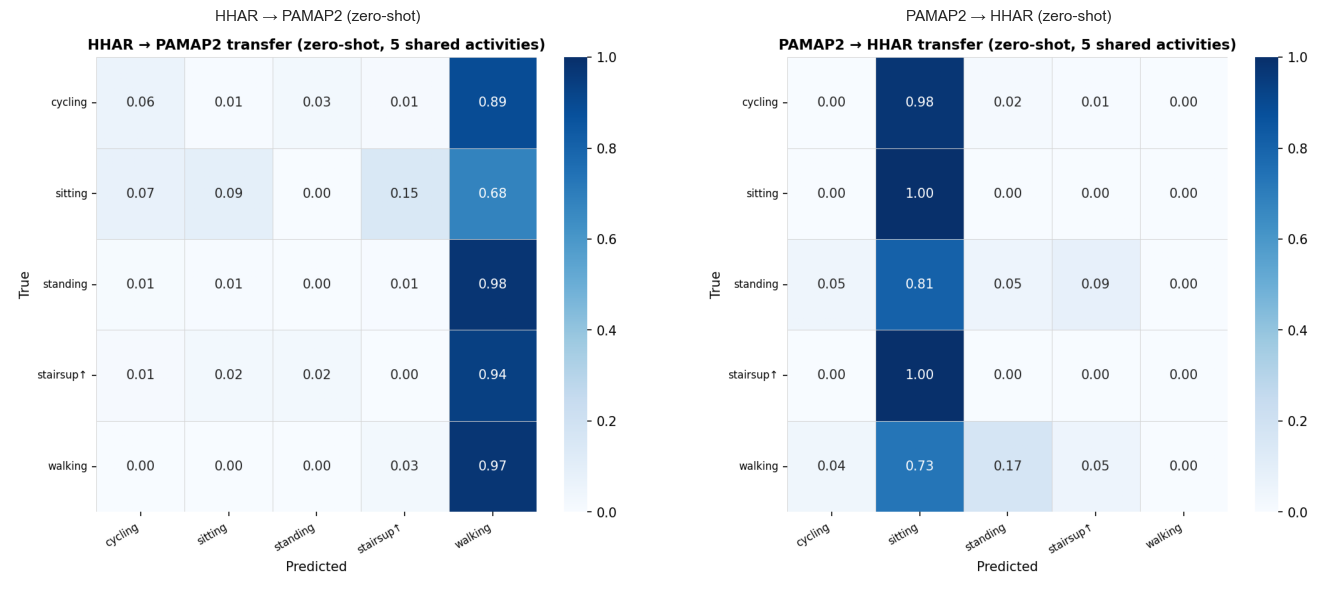

In [9]:
## Cross-Dataset Transfer Results
xfer_path = METS / 'cross_dataset_transfer_improved.json'
if xfer_path.exists():
    xfer = json.load(open(xfer_path))
    results = xfer.get('results', xfer) if isinstance(xfer, dict) else xfer
    shared   = xfer.get('shared_activities', ['cycling','sitting','standing','stairsup','walking'])
    ch_info  = xfer.get('channel_info', 'HHAR: acc x/y/z (ch0-2); PAMAP2: wrist acc1_x/y/z (ch0-2)')
    print("Cross-Dataset Transfer — ImprovedGNNLSTM (zero-shot, 5 shared activities)")
    print(f"  Shared activities: {', '.join(shared)}")
    print(f"  Channel alignment: {ch_info}\n")
    print(f"  {'Direction':<25} {'Accuracy':>10} {'Macro-F1':>10} {'Bal-Acc':>10}")
    print(f"  {'─'*25} {'─'*10} {'─'*10} {'─'*10}")
    for r in results:
        print(f"  {r['direction']:<25} {r['acc']:>10.4f} {r['f1']:>10.4f} {r['bacc']:>10.4f}")
    print()
    print("  Interpretation: Low transfer accuracy confirms a large domain gap between")
    print("  HHAR (unconstrained phone/watch) and PAMAP2 (controlled wrist IMU lab).")
    print("  Models collapse to majority-class predictions on unseen sensor distributions.")

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(axes,
    ['cm_transfer_hhar2pamap2.png', 'cm_transfer_pamap2hhar.png'],
    ['HHAR → PAMAP2 (zero-shot)', 'PAMAP2 → HHAR (zero-shot)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

## 9. Statistical Significance — Paired t-Tests

Paired t-tests on matched LOSO fold accuracies (9 pairs per comparison). Pairing by fold ensures each test subject appears once in each model's held-out set, making the comparison within-subject controlled.

In [10]:
## Statistical Significance (Extended)
sig_path = METS / 'significance_extended.json'
if sig_path.exists():
    sig = json.load(open(sig_path))
    print("Paired t-tests — fold-matched accuracy (9 LOSO folds)")
    print(f"\n  {'Comparison':<50} {'Δ mean':>8} {'p-value':>10} {'sig p<0.05':>12}")
    print(f"  {'─'*50} {'─'*8} {'─'*10} {'─'*12}")
    for k, v in sig.items():
        if 'legacy' in k:
            continue
        comp  = v['comparison']
        delta = v['delta_mean']
        p     = v['p_value']
        sig_  = "YES ★" if v['significant_p05'] else "no"
        print(f"  {comp:<50} {delta:>+8.4f} {p:>10.4f} {sig_:>12}")

    print()
    print("  Note: n=9 folds gives limited power for significance testing.")
    print("  A non-significant result does not mean no effect — it may reflect")
    print("  high fold-to-fold variance (large ±std) rather than absence of improvement.")

Paired t-tests — fold-matched accuracy (9 LOSO folds)

  Comparison                                           Δ mean    p-value   sig p<0.05
  ────────────────────────────────────────────────── ──────── ────────── ────────────
  ImprovedGNNLSTM vs GNN+LSTM(old)                    +0.0429     0.5976           no
  AttnAdj vs ImprovedGNNLSTM                          +0.0994     0.1238           no
  AttnAdj vs ImprovedGNNLSTM                          -0.0196     0.3429           no

  Note: n=9 folds gives limited power for significance testing.
  A non-significant result does not mean no effect — it may reflect
  high fold-to-fold variance (large ±std) rather than absence of improvement.
